Chapter 5: Optimal Stopping Theory

Optimal Stopping Theory is a branch of mathematics and decision science focused on finding the absolute best time to take a specific action to maximize reward or minimize cost when dealing with unknown future choices.

1. The Core Dilemma
When making choices over time—like buying a house, hiring an candidate, or picking a spot to park —-> you usually face two risks:

Stopping too early: You accept an option that is decent, but you miss out on a much better option down the road.

Stopping too late: You keep searching for perfection, pass up great options, and end up having to settle for a worse option (or nothing at all) because previous choices are no longer available.

2. The Classic Problem: The Secretary ProblemThe classic example used to explain Chapter 5's concepts is The Secretary Problem (also known as the Marriage Problem or the Choice Problem).
3. The Setup:
4. You are interviewing $N$ candidates for a single job position one by one.
5. After each interview, you must decide immediately whether to hire that candidate or reject them forever.
6. You can rank the current candidate relative to everyone you have interviewed so far, but you cannot see future candidates.
7. Your goal is to maximize the probability of picking the single best candidate in the entire pool.

4. Key Takeaways
Information vs. Action: Early stages should focus on gathering information to establish a baseline; later stages should focus on taking action based on that baseline.

Define Your Bounds: To apply optimal stopping, you need an estimate of either the total amount of time you have or the total number of options available (N).

When N is Flexible: If options are costly to inspect, the optimal stopping threshold drops over time—meaning your standards should naturally adjust as time or resources run out.

In [19]:
def ost(candidates, window_size):
    if window_size <= 0:
        return candidates[0] # no observation window --> return the first candidate 
    window_size = min(window_size, len(candidates) - 1) #validation of window_size being in range
    observedBest = candidates[0]
    for candidate in candidates[1:window_size]:
        if candidate > observedBest:
            observedBest = candidate 
    for candidate in candidates[window_size:len(candidates)]:
        if candidate > observedBest: #early exit
            return candidate
    return candidates[len(candidates) - 1] #return last candidate 
    #return candidates[-1] #negative index allows counting from the end 

In [20]:
#data structure 
pList = []

pList.append([1, 3, 2])
pList.append([1, 2, 3])
pList.append([3, 1, 2])
pList.append([3, 2, 1])
pList.append([2, 1, 3])
pList.append([2, 3, 1])

In [21]:
#simulating all permutation
window_size = 2
for candidates in pList:
    best = max(candidates)
    picked = ost(candidates, window_size) #candidates is a list 

    if best == picked:
        print(candidates, "window size:", window_size)
        

[1, 2, 3] window size: 2
[2, 1, 3] window size: 2


In [22]:
#simulate all windows
numOfWinSize = 3
bestPicked = [0] * numOfWinSize

# Simulate all different window sizes
for window_size in range(numOfWinSize):

    for candidates in pList:
        best = max(candidates)
        picked = ost(candidates, window_size)

        if best == picked:
            print(candidates, "window size:", window_size)
            bestPicked[window_size] += 1

print("Best picked:", bestPicked)

[3, 1, 2] window size: 0
[3, 2, 1] window size: 0
[1, 3, 2] window size: 1
[2, 1, 3] window size: 1
[2, 3, 1] window size: 1
[1, 2, 3] window size: 2
[2, 1, 3] window size: 2
Best picked: [2, 3, 2]


In [23]:
#Random sequences 
import random 
numOfCandidates = 10
candidates = []

for i in range(numOfCandidates):
    candidates.append(random.randint(1, 100)) #specifying range
print(candidates)

N = 10000
pList = []

for n in range(N):
    candidates = []

    for i in range(10):
        candidates.append(random.randint(1, 100))
    pList.append(candidates)
print(pList[0:10])

[34, 57, 96, 65, 84, 82, 27, 11, 69, 94]
[[70, 15, 37, 99, 94, 68, 45, 59, 1, 37], [12, 54, 70, 27, 92, 49, 15, 61, 52, 80], [94, 97, 25, 100, 79, 62, 45, 8, 77, 68], [83, 65, 82, 100, 69, 39, 18, 65, 15, 51], [23, 39, 67, 23, 18, 37, 74, 15, 63, 70], [14, 6, 76, 34, 31, 31, 17, 16, 13, 59], [87, 31, 76, 83, 27, 99, 40, 76, 57, 17], [20, 82, 69, 78, 49, 63, 22, 72, 13, 86], [83, 99, 47, 15, 44, 42, 50, 79, 93, 67], [42, 26, 22, 62, 33, 25, 59, 95, 59, 99]]


In [24]:
#Optimal stopping theory
bestPicked = [0] * numOfCandidates

for window_size in range(numOfCandidates):

    for candidates in pList:
        best = max(candidates)
        picked = ost(candidates, window_size)

        if best == picked:
        #print(candidates, "window_size:", window_size)
            bestPicked[window_size] += 1
print("Best Picked:", bestPicked) #to observe the optimal stopping line 

Best Picked: [1043, 2906, 3677, 3985, 3954, 3669, 3279, 2644, 1935, 1047]


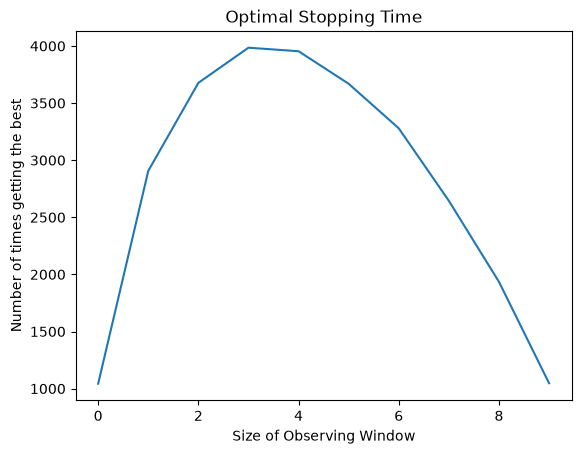

In [25]:
# importing the modules
import numpy as np
import matplotlib.pyplot as plt

# data to be plotted
x = range(numOfCandidates)
y = bestPicked

# plotting
plt.title("Optimal Stopping Time")
plt.xlabel("Size of Observing Window")
plt.ylabel("Number of times getting the best")
plt.plot(x, y)
plt.show()

In [26]:
# itertools section
from itertools import permutations

bpList = list(permutations(range(numOfCandidates)))

# List slicing: elements from the beginning
#generating all permutations 
print(bpList[:10])

[(0, 1, 2, 3, 4, 5, 6, 7, 8, 9), (0, 1, 2, 3, 4, 5, 6, 7, 9, 8), (0, 1, 2, 3, 4, 5, 6, 8, 7, 9), (0, 1, 2, 3, 4, 5, 6, 8, 9, 7), (0, 1, 2, 3, 4, 5, 6, 9, 7, 8), (0, 1, 2, 3, 4, 5, 6, 9, 8, 7), (0, 1, 2, 3, 4, 5, 7, 6, 8, 9), (0, 1, 2, 3, 4, 5, 7, 6, 9, 8), (0, 1, 2, 3, 4, 5, 7, 8, 6, 9), (0, 1, 2, 3, 4, 5, 7, 8, 9, 6)]


The optimal stopping strategy would
give us a 37% chance of obtaining the
optimal value.